In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df=pd.read_csv("results1/single_var/data.csv")
print(df.columns)
print("shape",df.shape)

Index(['p', 'D', 'seed', 'DX', 'D_diff', 'time', 'abs_theta'], dtype='object')
shape (76000, 7)


In [46]:
p_list=df['p'].unique()

In [47]:
df=df[df["p"]==p_list[0]]
print("shape",df.shape)

shape (38000, 7)


In [48]:
dx_list=df["DX"].unique()
print(dx_list)

[0.03571429 0.05357143 0.07142857 0.08928571 0.10714286]


In [49]:
df=df[df["DX"]==dx_list[4]]

In [50]:
df.head()

,p,D,seed,DX,D_diff,time,abs_theta
3040,0.0,0.0,10,0.107143,0.0,0.00,0.055891
3041,0.0,0.0,10,0.107143,0.0,0.01,0.176761
3042,0.0,0.0,10,0.107143,0.0,0.02,0.120007
3043,0.0,0.0,10,0.107143,0.0,0.03,0.085128
3044,0.0,0.0,10,0.107143,0.0,0.04,0.352572


In [51]:

df=df[df["time"]==0.75]
print("shape",df.shape)

shape (100, 7)


In [52]:
df.head()

,p,D,seed,DX,D_diff,time,abs_theta
3115,0.0,0.0,10,0.107143,0.0,0.75,0.276001
3191,0.0,0.0,10,0.107143,5.0,0.75,0.167439
3267,0.0,0.0,10,0.107143,10.0,0.75,0.182589
3343,0.0,0.0,10,0.107143,15.0,0.75,0.099775
3419,0.0,0.0,10,0.107143,20.0,0.75,0.003517


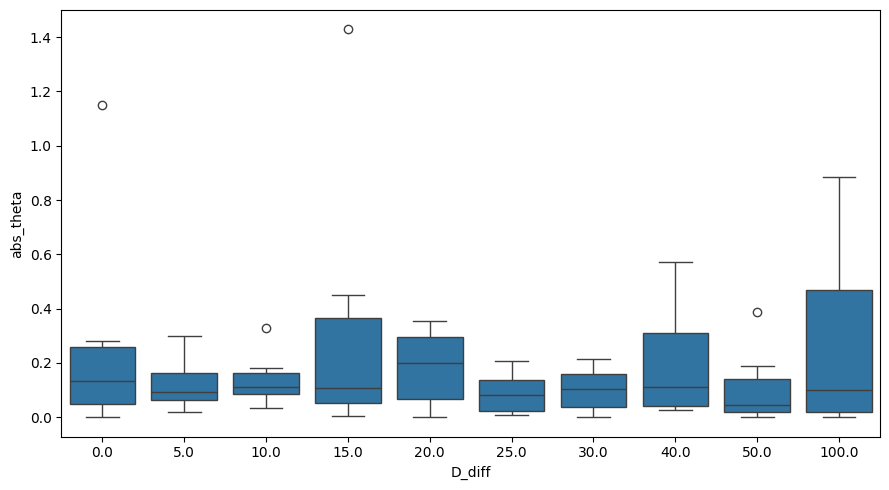

In [53]:
plt.figure(figsize=(9, 5))

df["D_diff"] = df["D_diff"].astype("category")
sns.boxplot(data=df, x="D_diff", y="abs_theta")
plt.tight_layout()

In [54]:
df["D_diff"] = df["D_diff"].astype("category")

summary = (
    df.groupby("D_diff")["abs_theta"]
    .agg(mean="mean", std="std")
    .sort_values("mean")
    .reset_index()
)

print(summary.to_string(index=False))

D_diff     mean      std
  25.0 0.087167 0.068965
  50.0 0.098399 0.119792
  30.0 0.105228 0.076456
   5.0 0.119728 0.082111
  10.0 0.129273 0.086228
  20.0 0.178416 0.135100
  40.0 0.190878 0.188101
   0.0 0.229317 0.340139
 100.0 0.263277 0.314656
  15.0 0.290685 0.428650


/var/folders/xr/y8fz998s0g5czf906q64rvx40000gn/T/ipykernel_1449/3395064099.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("D_diff")["abs_theta"]


/var/folders/xr/y8fz998s0g5czf906q64rvx40000gn/T/ipykernel_1449/3906487432.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("D_diff")["abs_theta"]


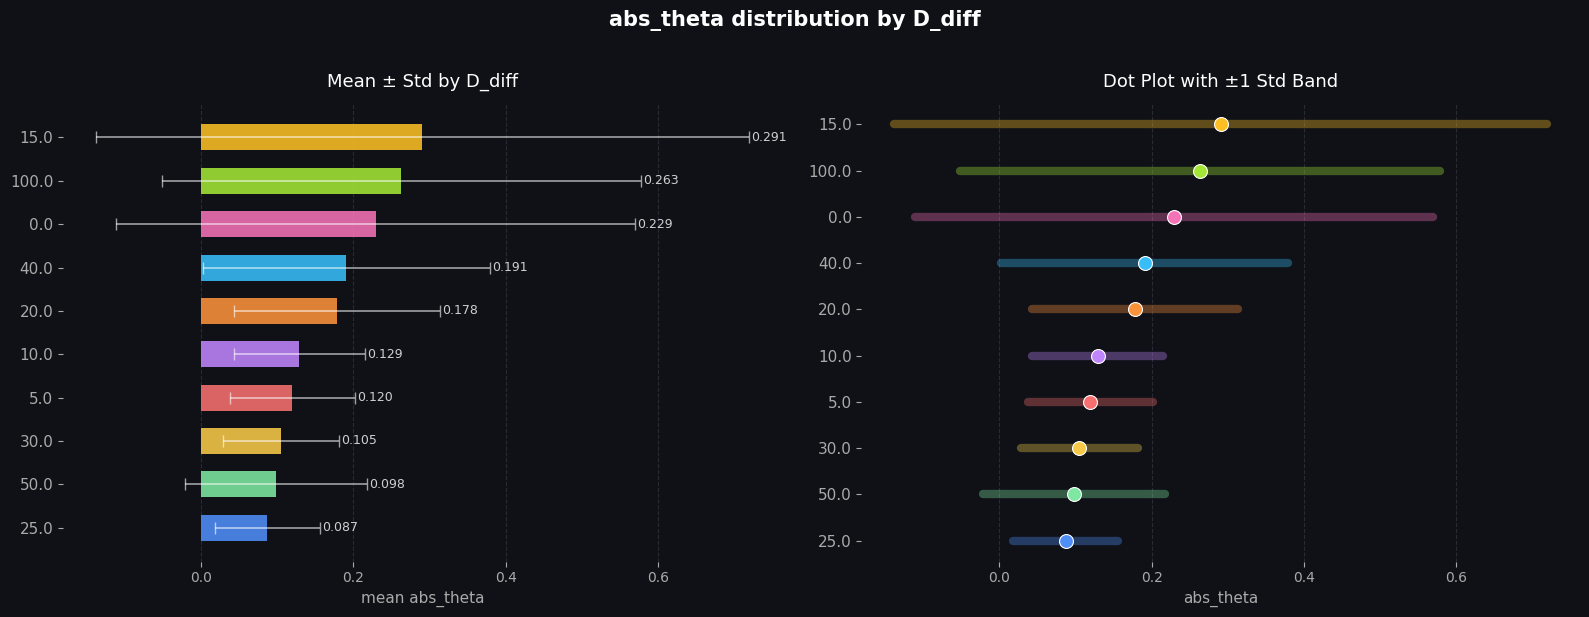

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df["D_diff"] = df["D_diff"].astype("category")

summary = (
    df.groupby("D_diff")["abs_theta"]
    .agg(mean="mean", std="std")
    .sort_values("mean")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")
for ax in axes:
    ax.set_facecolor("#0f1117")

PALETTE = ["#4f8ef7", "#7ee8a2", "#f7c948", "#f76f6f", "#c084fc",
           "#fb923c", "#38bdf8", "#f472b6", "#a3e635", "#fbbf24"]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(summary))]

# ── Plot 1: horizontal bar with error bars ──────────────────────────────────
ax1 = axes[0]
y_pos = np.arange(len(summary))
bars = ax1.barh(
    y_pos, summary["mean"],
    xerr=summary["std"],
    color=colors,
    error_kw=dict(ecolor="white", elinewidth=1.2, capsize=4, alpha=0.6),
    height=0.6,
    alpha=0.88,
)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(summary["D_diff"], color="white", fontsize=11)
ax1.set_xlabel("mean abs_theta", color="#aaaaaa", fontsize=11)
ax1.set_title("Mean ± Std by D_diff", color="white", fontsize=13, pad=12)
ax1.tick_params(colors="#aaaaaa")
ax1.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax1.xaxis.grid(True, color="#2a2a35", linewidth=0.8, linestyle="--")
ax1.set_axisbelow(True)

for bar, mean_val, std_val in zip(bars, summary["mean"], summary["std"]):
    ax1.text(
        bar.get_width() + std_val + (summary["mean"].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{mean_val:.3f}",
        va="center", ha="left", color="white", fontsize=9, alpha=0.8,
    )

# ── Plot 2: dot plot with std shading ────────────────────────────────────────
ax2 = axes[1]
for i, (_, row) in enumerate(summary.iterrows()):
    ax2.plot([row["mean"] - row["std"], row["mean"] + row["std"]],
             [i, i], color=colors[i], alpha=0.35, linewidth=6, solid_capstyle="round")
    ax2.scatter(row["mean"], i, color=colors[i], s=100, zorder=5, edgecolors="white", linewidths=0.8)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(summary["D_diff"], color="white", fontsize=11)
ax2.set_xlabel("abs_theta", color="#aaaaaa", fontsize=11)
ax2.set_title("Dot Plot with ±1 Std Band", color="white", fontsize=13, pad=12)
ax2.tick_params(colors="#aaaaaa")
ax2.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax2.xaxis.grid(True, color="#2a2a35", linewidth=0.8, linestyle="--")
ax2.set_axisbelow(True)

plt.suptitle("abs_theta distribution by D_diff", color="white", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("abs_theta_by_D_diff.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()